# Chapter 78 — Simulation vs Analytical Solutions

> **Prerequisites:** ch074 (Iterative Computation), ch076 (Dynamical Systems)
>
> **You will learn:**
> - Distinguish when to use analytical vs numerical solutions
> - Implement Euler's method for differential equations
> - Understand numerical error accumulation
> - Know when simulation is the only option
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Many mathematical problems have exact **analytical solutions** — closed-form formulas. Others have no closed form and require **numerical simulation**.

**Analytical solution:** Exact, infinite precision, no accumulated error. Example: f(x) = e^x solves f' = f, f(0) = 1.

**Numerical simulation:** Approximate, finite precision, error accumulates. Example: Euler's method approximates the solution by taking small steps.

**When simulation is necessary:**
- Non-linear ODEs (most real-world systems have no closed form)
- Systems with many interacting components
- Stochastic dynamics (random noise)
- Unknown governing equations (learn from data)

**Euler's method (simplest ODE solver):**
Given dx/dt = f(t, x), x(0) = x₀:
xₙ₊₁ = xₙ + h·f(tₙ, xₙ)

where h is the step size. Error is O(h) — halving h halves the error (first-order method).

*(This is a discrete dynamical system from ch076 applied to continuous differential equations.)*

---

## 2. Intuition & Mental Models

**Physical analogy:** Navigation by dead reckoning vs GPS. Dead reckoning (Euler's method) uses current speed and direction to estimate position after a small time step. Error accumulates. GPS gives the exact position. For short trips, dead reckoning works fine; for long voyages, errors compound.

**Computational analogy:** Animation in video games vs physics-based rendering. Game physics often uses Euler integration (fast, approximate); cinematic rendering uses exact ray tracing equations (slow, precise).

---

## 3. Visualization

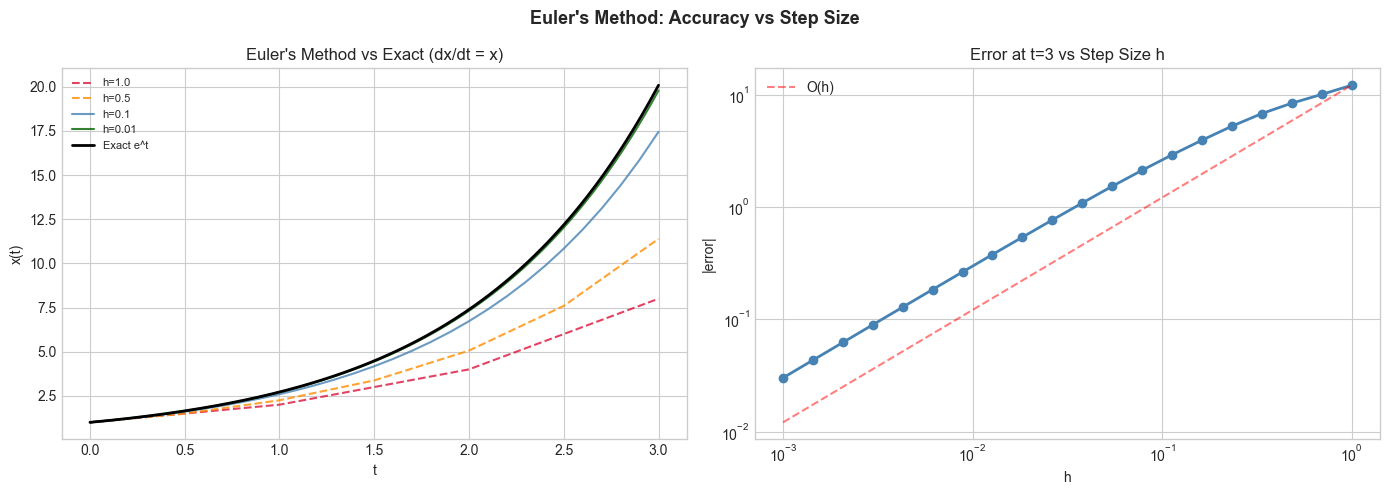

In [1]:
# --- Visualization: Euler vs exact solution for f' = f ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def euler_method(f, x0, t_start, t_end, h):
    """Euler's method: xₙ₊₁ = xₙ + h*f(tₙ, xₙ)."""
    ts = [t_start]
    xs = [x0]
    t, x = t_start, x0
    while t < t_end - 1e-10:
        h_actual = min(h, t_end - t)
        x = x + h_actual * f(t, x)
        t = t + h_actual
        ts.append(t); xs.append(x)
    return np.array(ts), np.array(xs)

# Solve dx/dt = x, x(0) = 1. Exact: x(t) = e^t
f_exp = lambda t, x: x
t_exact = np.linspace(0, 3, 300)
x_exact = np.exp(t_exact)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h, color in [(1.0, 'crimson'), (0.5, 'darkorange'), (0.1, 'steelblue'), (0.01, 'darkgreen')]:
    ts, xs = euler_method(f_exp, 1.0, 0, 3, h)
    axes[0].plot(ts, xs, color=color, linewidth=1.5, linestyle='--' if h > 0.1 else '-',
                 label=f'h={h}', alpha=0.8)

axes[0].plot(t_exact, x_exact, 'k-', linewidth=2, label='Exact e^t', zorder=5)
axes[0].set_title("Euler's Method vs Exact (dx/dt = x)")
axes[0].set_xlabel('t'); axes[0].set_ylabel('x(t)'); axes[0].legend(fontsize=8)

# Error vs step size
h_vals = np.logspace(-3, 0, 20)
errors = []
for h in h_vals:
    ts, xs = euler_method(f_exp, 1.0, 0, 3, h)
    errors.append(abs(xs[-1] - np.exp(3.0)))

axes[1].loglog(h_vals, errors, 'o-', color='steelblue', linewidth=2)
# Theoretical O(h) line
axes[1].loglog(h_vals, np.array(h_vals) * errors[-1] / h_vals[-1], 'r--', alpha=0.5, label='O(h)')
axes[1].set_title("Error at t=3 vs Step Size h"); axes[1].set_xlabel('h'); axes[1].set_ylabel('|error|')
axes[1].legend()

plt.suptitle("Euler's Method: Accuracy vs Step Size", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

In [2]:
# --- Implementation: ODE solver comparison ---
import numpy as np

def euler(f, x0, t_span, h):
    """First-order Euler method."""
    t0, t1 = t_span
    ts, xs = [t0], [float(x0)]
    t, x = t0, float(x0)
    while t < t1 - 1e-10:
        h_act = min(h, t1 - t)
        x += h_act * f(t, x)
        t += h_act
        ts.append(t); xs.append(x)
    return np.array(ts), np.array(xs)

def rk4(f, x0, t_span, h):
    """Fourth-order Runge-Kutta: error O(h⁴)."""
    t0, t1 = t_span
    ts, xs = [t0], [float(x0)]
    t, x = t0, float(x0)
    while t < t1 - 1e-10:
        h_act = min(h, t1 - t)
        k1 = f(t, x)
        k2 = f(t + h_act/2, x + h_act*k1/2)
        k3 = f(t + h_act/2, x + h_act*k2/2)
        k4 = f(t + h_act, x + h_act*k3)
        x += h_act * (k1 + 2*k2 + 2*k3 + k4) / 6
        t += h_act
        ts.append(t); xs.append(x)
    return np.array(ts), np.array(xs)

# Compare on dx/dt = -x (decay), exact: x(t) = e^(-t)
f_decay = lambda t, x: -x
x0, t_span, h = 1.0, (0, 5), 0.5
exact_end = np.exp(-5)

_, xs_euler = euler(f_decay, x0, t_span, h)
_, xs_rk4 = rk4(f_decay, x0, t_span, h)

print(f"At t=5, h=0.5:")
print(f"  Exact:   {exact_end:.10f}")
print(f"  Euler:   {xs_euler[-1]:.10f}  (error: {abs(xs_euler[-1]-exact_end):.2e})")
print(f"  RK4:     {xs_rk4[-1]:.10f}  (error: {abs(xs_rk4[-1]-exact_end):.2e})")

At t=5, h=0.5:
  Exact:   0.0067379470
  Euler:   0.0009765625  (error: 5.76e-03)
  RK4:     0.0067646755  (error: 2.67e-05)


---

## 6. Experiments

**Experiment 1:** Solve dx/dt = -x² (exact: x(t) = 1/(1+t)) with Euler and RK4 at h=0.5, 0.1, 0.01. Compare accuracy at t=2.

**Experiment 2:** Simulate the SIR epidemic model (3 coupled ODEs) using Euler's method and compare results for h=0.1 vs h=0.01. How sensitive is the peak timing to step size?

---

## 7. Exercises

**Easy 1.** Use Euler's method to solve dx/dt = 2t, x(0) = 0 from t=0 to t=3 with h=0.5. Compare to exact x(t) = t².

**Easy 2.** When is an analytical solution always preferred over simulation? Give two reasons.

**Medium 1.** Implement midpoint method: xₙ₊₁ = xₙ + h·f(tₙ + h/2, xₙ + h/2·f(tₙ, xₙ)). This is second-order (error O(h²)). Verify by checking error scales as h² not h.

**Medium 2.** Implement the harmonic oscillator: dx/dt = v, dv/dt = -x (pendulum). Use Euler and RK4. Both oscillate but Euler's energy drifts — verify by computing x² + v² (should be constant).

**Hard.** Implement adaptive step size control: if |rk4_step - euler_step| > tolerance, halve h; if it's much less, double h. This is the basis of scipy's `solve_ivp` with `method='RK45'`. Apply to a stiff ODE: dx/dt = -1000x + cos(t).

---

## 9. Chapter Summary & Connections

- Analytical solutions: exact, no error, but rare for nonlinear systems
- Euler's method: first-order accuracy O(h); straightforward but accumulates error
- RK4: fourth-order accuracy O(h⁴); four function evaluations per step, much more accurate
- All simulation introduces error that grows with time — step size controls the rate

**Forward connections:**
- ch225 (Differential Equations) treats ODEs systematically
- ch226 (Simulation of Differential Systems) builds epidemic and mechanical simulations
- Numerical integration connects to quadrature in ch223